In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier


In [2]:
train = pd.read_parquet(r"C:\Users\Vineet\Desktop\Network_Intrusion_Project\data\UNSW_NB15_training-set.parquet")
test  = pd.read_parquet(r"C:\Users\Vineet\Desktop\Network_Intrusion_Project\data\UNSW_NB15_testing-set.parquet")

print("Train shape:", train.shape)
print("Test shape:", test.shape)


Train shape: (175341, 36)
Test shape: (82332, 36)


In [3]:
features = [
    "dur",
    "proto",
    "spkts",
    "dpkts",
    "sbytes",
    "dbytes",
    "rate",
    "sload",
    "dload",
    "ct_src_dport_ltm",
    "ct_dst_sport_ltm",
    "is_ftp_login",
    "ct_ftp_cmd"
]

train = train[features + ["label"]]
test  = test[features + ["label"]]


In [4]:
print("Missing values (train):\n", train.isnull().sum())
print("Missing values (test):\n", test.isnull().sum())


Missing values (train):
 dur                 0
proto               0
spkts               0
dpkts               0
sbytes              0
dbytes              0
rate                0
sload               0
dload               0
ct_src_dport_ltm    0
ct_dst_sport_ltm    0
is_ftp_login        0
ct_ftp_cmd          0
label               0
dtype: int64
Missing values (test):
 dur                 0
proto               0
spkts               0
dpkts               0
sbytes              0
dbytes              0
rate                0
sload               0
dload               0
ct_src_dport_ltm    0
ct_dst_sport_ltm    0
is_ftp_login        0
ct_ftp_cmd          0
label               0
dtype: int64


In [5]:
le = LabelEncoder()

train["proto"] = le.fit_transform(train["proto"])
test["proto"]  = le.transform(test["proto"])


In [6]:
X_train = train.drop("label", axis=1)
y_train = train["label"]

X_test = test.drop("label", axis=1)
y_test = test["label"]


In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)   # fit ONLY on train
X_test  = scaler.transform(X_test)        # transform test


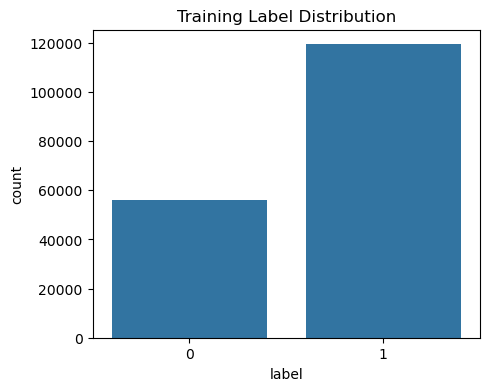

In [8]:
plt.figure(figsize=(5,4))
sns.countplot(x=y_train)
plt.title("Training Label Distribution")
plt.show()


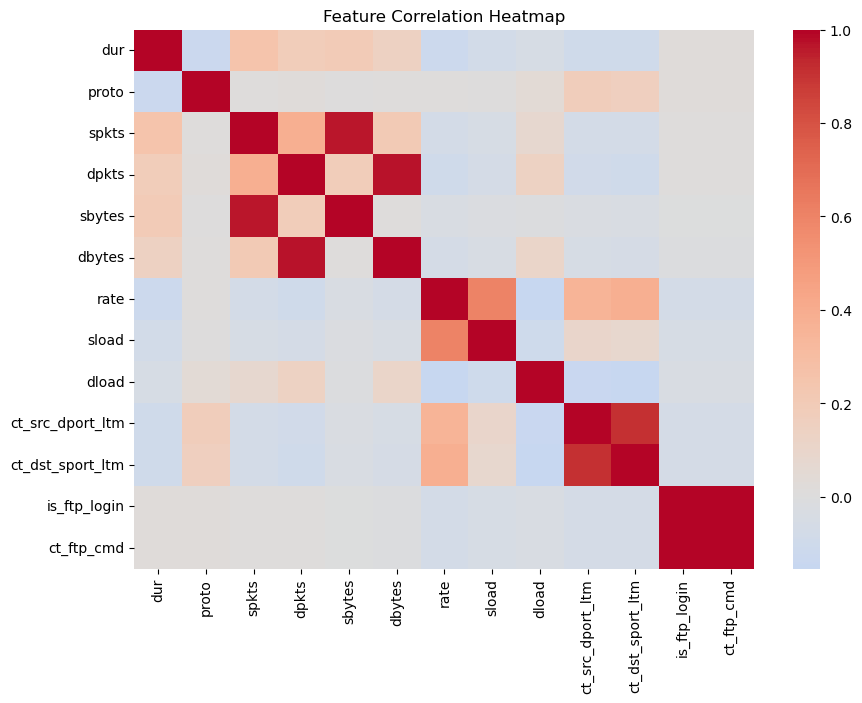

In [9]:
plt.figure(figsize=(10,7))
sns.heatmap(pd.DataFrame(X_train, columns=features).corr(),
            cmap="coolwarm", center=0)
plt.title("Feature Correlation Heatmap")
plt.show()


In [10]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42)
}


MODEL: Logistic Regression
Accuracy: 0.7163192926201234

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.41      0.56     37000
           1       0.67      0.97      0.79     45332

    accuracy                           0.72     82332
   macro avg       0.79      0.69      0.68     82332
weighted avg       0.78      0.72      0.69     82332



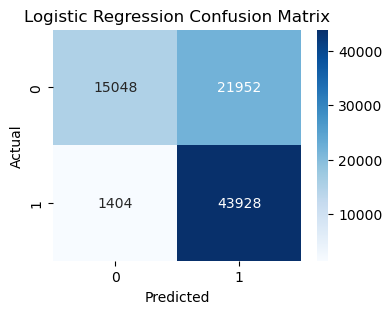


MODEL: Decision Tree
Accuracy: 0.8633581110625274

Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.75      0.83     37000
           1       0.82      0.96      0.89     45332

    accuracy                           0.86     82332
   macro avg       0.88      0.85      0.86     82332
weighted avg       0.87      0.86      0.86     82332



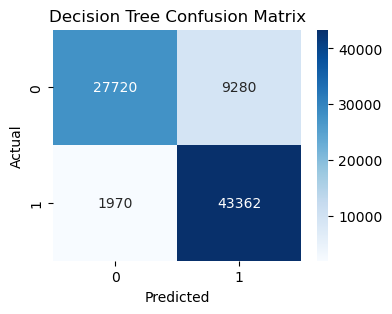


MODEL: Random Forest
Accuracy: 0.8673541271923432

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.74      0.83     37000
           1       0.82      0.97      0.89     45332

    accuracy                           0.87     82332
   macro avg       0.89      0.86      0.86     82332
weighted avg       0.88      0.87      0.86     82332



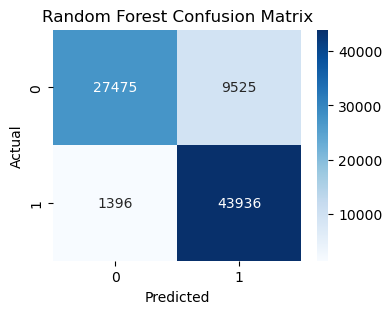

In [11]:
results = {}
roc_data = {}

for name, model in models.items():
    
    print("\n==============================")
    print("MODEL:", name)
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    
    print("Accuracy:", acc)
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
    
    # ROC
    y_prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    
    roc_data[name] = (fpr, tpr, roc_auc)


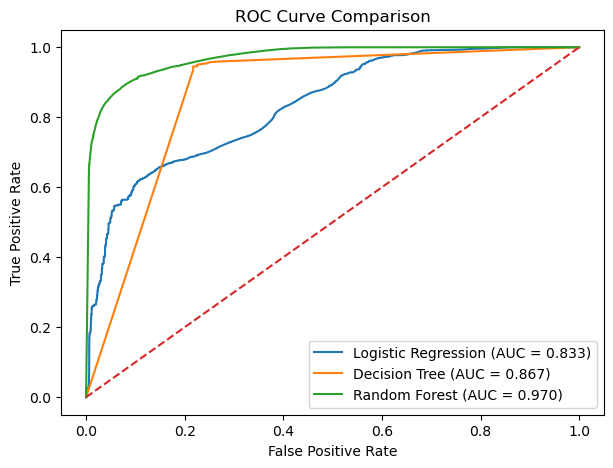

In [12]:
plt.figure(figsize=(7,5))

for name, (fpr, tpr, roc_auc) in roc_data.items():
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()
plt.show()


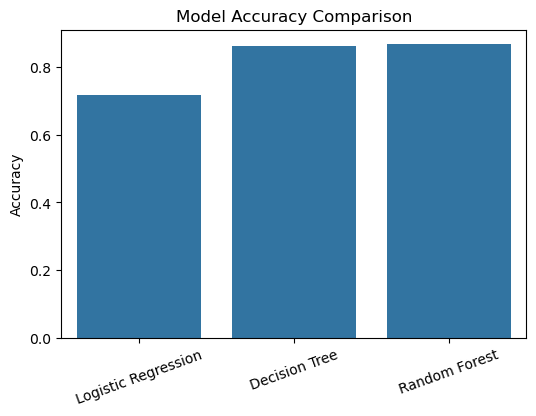

In [13]:
plt.figure(figsize=(6,4))
sns.barplot(x=list(results.keys()), y=list(results.values()))
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
plt.xticks(rotation=20)
plt.show()


In [14]:
print("\n===== CROSS VALIDATION (TRAIN SET) =====")

for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5)
    print(name, "CV Accuracy:", scores.mean())



===== CROSS VALIDATION (TRAIN SET) =====
Logistic Regression CV Accuracy: 0.8500289931768823
Decision Tree CV Accuracy: 0.9058633893364156
Random Forest CV Accuracy: 0.9068613949530896
